# 基于机器学习的医疗二分类预测模型(论文技术复现)

## 论文信息
**原论文**: 基于机器学习的非心肺转流冠状动脉旁路移植术相关急性肾损伤的预测模型

## 复现说明
- 由于原论文所用的 OPCABG-AKI 临床数据集为医院私有数据,本复现选用 **scikit-learn 自带的威斯康星乳腺癌诊断数据集** （Breast Cancer Wisconsin Diagnostic Dataset） 作为替代。
- 该数据集同属医疗领域二分类问题(良性 vs 恶性),包含 569 例样本、30 个数值特征,


## 复现的技术内容(对照原论文)
1. **数据预处理**: 缺失值插补(均值/众数) —— 模拟原论文中 `<10%` 比例的插补策略
2. **数据集划分**: 训练集 : 测试集 = 7 : 3 (原论文相同比例)
3. **8 种机器学习模型**: LR, DT, KNN, SVM, RF, GBDT, XGBoost, LightGBM
4. **5 折交叉验证**: 防止建模过拟合
5. **性能评估**: Accuracy, Precision, Recall, F1-score, ROC AUC (95%CI)
6. **ROC 曲线图**: 8 种模型的 ROC 曲线对比 (复现论文图1)
7. **校准曲线**: 模型预测概率的准确性对比 (复现论文图2)
8. **SHAP 可解释性分析** (论文核心):
   - 特征重要性排序 —— SHAP 绝对值均值 (复现论文图3A)
   - 特征正/负影响分析 —— 蜂群图 summary_plot (复现论文图3B)
   - 单特征量化分析 —— 依赖图 dependence_plot (复现论文图4)
   - 真阳性 / 真阴性样本的独立解释 —— force_plot (复现论文图5)


## 1. 导入所需库

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)
from sklearn.calibration import calibration_curve

# 梯度提升库
import xgboost as xgb
import lightgbm as lgb

# SHAP 可解释性
import shap

# 设置随机种子以保证可复现
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# matplotlib 样式
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

#结果保存目录
save_dir = "result"
os.makedirs(save_dir, exist_ok=True)

print('所有库导入成功')
print(f'SHAP 版本: {shap.__version__}')
print(f'XGBoost 版本: {xgb.__version__}')
print(f'LightGBM 版本: {lgb.__version__}')


## 2. 加载医疗数据集并进行探索性分析

原论文基于 1110 例 OPCABG 患者的围手术期临床数据(人口学特征、术前化验、术中血流动力学、用药量等),
构建二分类模型预测术后是否发生 AKI。

此处使用的威斯康星乳腺癌数据集也是医疗二分类任务：根据细胞核的 30 个形态学特征预测肿瘤良恶性。
- **样本数**: 569 例
- **特征数**: 30 个数值型特征
- **标签**: 0 = 恶性(相当于原论文 "AKI 发生"),1 = 良性(相当于 "未发生 AKI")。实际操作时，反转标签，1为恶性（阳性），0为良性（阴性）


威斯康星**乳腺癌数据集**介绍：

- 数据集来自美国威斯康星州的乳腺癌诊断数据集，医疗人员采集了患者乳腺肿块经过细针穿刺 (FNA) 后的数字化图像，并且对这些数字图像进行了特征提取，这些特征可以描述图像中的细胞核呈现。肿瘤可以分成良性和恶性。

- 下面的表格中，mean 代表平均值，se 代表标准差，worst 代表最大值（3 个最大值的平均值）。

- 每张图像都计算了相应的特征，得出了这 30 个特征值（不包括 ID 字段和分类标识结果字段 diagnosis），实际上是 10 个特征值（radius、texture、perimeter、area、smoothness、compactness、concavity、concave points、symmetry 和fractal_dimension_mean）的 3 个维度，平均、标准差和最大值。

- 这些特征值都保留了4 位数字。

- 字段中没有缺失的值。

- 在 569 个患者中，一共有 357 个是良性，212 个是恶性。

<img src="./assets/datasets_description.jpg" width=600>


In [34]:
# 加载乳腺癌数据集
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# 为了和原论文保持一致的语义(1 = 发生事件, 0 = 未发生),反转标签
# 原标签: 0=malignant(恶性), 1=benign(良性)
# 反转后: 1=malignant(阳性事件, 恶性)), 0=benign(阴性事件, 良性)  —— 类似论文中 AKI 的定义
y = 1 - y

print(f'数据集形状: {X.shape}')
print(f'特征数: {X.shape[1]}')
print(f'样本数: {X.shape[0]}')
print(f'\n阳性样本(恶性)数量: {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')
print(f'阴性样本(良性)数量: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')


数据集形状: (569, 30)
特征数: 30
样本数: 569

阳性样本(恶性)数量: 212 (37.3%)
阴性样本(良性)数量: 357 (62.7%)


In [35]:
# radius error : 半径的标准误差
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [36]:
# 保存数据集
df = pd.concat([y, X], axis=1)
df.to_excel(os.path.join(save_dir, "breast_cancer.xlsx"), index=False)
df

,target,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


## 3. 缺失值处理(复现论文"缺失值处理"章节)

原论文策略:
> 对于缺失比例<10%的特征参数,使用缺失值插补方式不会对结果产生偏倚,
> 数值变量采用**均值插补**,分类变量采用**众数插补**。其余特征予以剔除。

乳腺癌数据集本身没有缺失值,此处我们**随机注入缺失值**来模拟真实临床数据,
并按论文策略进行均值插补。


In [37]:
# 模拟真实临床数据的缺失情况 —— 随机注入 5% 缺失。
np.random.seed(RANDOM_STATE)
X_missing = X.copy()
n_missing = int(X.size * 0.05)
missing_indices = [(np.random.randint(0, X.shape[0]), np.random.randint(0, X.shape[1]))
                   for _ in range(n_missing)]
for i, j in missing_indices:
    X_missing.iat[i, j] = np.nan

# 查看每个特征的缺失比例
missing_ratio = X_missing.isna().mean().sort_values(ascending=False)
print('每个特征的缺失比例(前 10 个):')
print((missing_ratio.head(10) * 100).round(2).astype(str) + ' %')
print(f'\n总缺失单元格: {X_missing.isna().sum().sum()} / {X.size} ({X_missing.isna().sum().sum()/X.size*100:.2f}%)')

每个特征的缺失比例(前 10 个):
symmetry error              6.5 %
worst compactness          6.33 %
mean smoothness            6.33 %
mean texture               6.15 %
mean perimeter             6.15 %
mean radius                5.98 %
worst fractal dimension     5.8 %
worst perimeter            5.45 %
worst symmetry             5.45 %
worst smoothness           5.45 %
dtype: object

总缺失单元格: 828 / 17070 (4.85%)


In [38]:
# 置为空值后的缺失数据
X_missing

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,NaN,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,NaN,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,NaN,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,NaN,0.10430,0.1809,0.05883,...,22.540,16.67,NaN,1575.0,0.13740,NaN,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,NaN,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,NaN,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,NaN,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [39]:
# 按论文策略:缺失比例 < 10% 的特征使用均值插补。
# 乳腺癌数据全部为数值变量,故全部使用均值插补
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_missing),
    columns=X.columns
)

print(f'插补后缺失总数: {X_imputed.isna().sum().sum()}')
print(f'插补后数据形状: {X_imputed.shape}')

插补后缺失总数: 0
插补后数据形状: (569, 30)


In [40]:
# 原始数据
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [41]:
# 调整后的数据
X_imputed

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.990000,10.38,92.001105,1001.0,0.118400,0.27760,0.300100,0.14710,0.2419,0.07871,...,25.380,25.727721,184.600000,2019.0,0.16220,0.665600,0.7119,0.2654,0.4601,0.11890
1,14.145202,17.77,132.900000,1326.0,0.084740,0.07864,0.086900,0.07017,0.1812,0.05667,...,24.990,23.410000,158.800000,1956.0,0.12380,0.186600,0.2416,0.1860,0.2750,0.08902
2,19.690000,21.25,130.000000,1203.0,0.109600,0.15990,0.197400,0.12790,0.2069,0.05999,...,23.570,25.530000,152.500000,1709.0,0.14440,0.424500,0.4504,0.2430,0.3613,0.08758
3,11.420000,20.38,77.580000,386.1,0.142500,0.28390,0.241400,0.10520,0.2597,0.09744,...,14.910,26.500000,98.870000,567.7,0.20980,0.866300,0.6869,0.2575,0.6638,0.17300
4,20.290000,14.34,135.100000,1297.0,0.100300,0.13280,0.088263,0.10430,0.1809,0.05883,...,22.540,16.670000,106.657546,1575.0,0.13740,0.255009,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.560000,22.39,142.000000,1479.0,0.096147,0.11590,0.243900,0.13890,0.1726,0.05623,...,25.450,26.400000,106.657546,2027.0,0.14100,0.211300,0.4107,0.2216,0.2060,0.07115
565,20.130000,28.25,131.200000,1261.0,0.097800,0.10340,0.144000,0.09791,0.1752,0.05533,...,23.690,38.250000,155.000000,1731.0,0.11660,0.255009,0.3215,0.1628,0.2572,0.06637
566,16.600000,28.08,108.300000,858.1,0.084550,0.10230,0.092510,0.05302,0.1590,0.05648,...,18.980,34.120000,126.700000,1124.0,0.11390,0.309400,0.3403,0.1418,0.2218,0.07820
567,20.600000,29.33,140.100000,1265.0,0.117800,0.27700,0.351400,0.15200,0.2397,0.07016,...,25.740,39.420000,184.600000,1821.0,0.16500,0.868100,0.9387,0.2650,0.4087,0.12400


## 4. 训练集/测试集划分(7:3)

原论文:
> 使用 sklearn 模块中 train_test_split 工具将预处理数据按 7:3 比例随机划分成训练集和测试集。


### 4.1 拆分数据集

In [42]:
# 按 7:3 划分,并用 stratify 保持阳性/阴性样本比例一致
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.3,
    stratify=y,  # 标签按比例拆分
    random_state=RANDOM_STATE
)

print(f'训练集: {X_train.shape[0]} 例 (阳性 {(y_train==1).sum()} 例, 阴性 {(y_train==0).sum()} 例)')
print(f'测试集: {X_test.shape[0]}  例 (阳性 {(y_test==1).sum()}  例, 阴性 {(y_test==0).sum()}  例)')
print(f'训练集阳性比例: {y_train.mean()*100:.1f}%')
print(f'测试集阳性比例: {y_test.mean()*100:.1f}%')

训练集: 398 例 (阳性 148 例, 阴性 250 例)
测试集: 171  例 (阳性 64  例, 阴性 107  例)
训练集阳性比例: 37.2%
测试集阳性比例: 37.4%


### 4.2 数据压缩

In [43]:
# 数据压缩：标准化处理（还可以用归一化)。注意，如果模型不接受负数，可以选择归一化处理。
scaler = StandardScaler()
scaler.fit(X_train)  # 只能训练集，不能全部数据 
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),    columns=X_test.columns,  index=X_test.index)

In [44]:
# 压缩后训练集
X_train_scaled

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
78,1.744380,1.101662,2.156552,1.692201,2.341398,4.707010,3.628561,2.896318,4.078583,2.663198,...,1.467657,0.949626,1.956769,1.330715,1.370650,2.348090,2.424429,2.084975,4.106464,0.890535
330,0.548168,-0.928344,0.565132,0.390123,-0.057466,0.669931,0.408382,0.563018,-0.117937,-0.419146,...,0.505009,-0.670001,0.538419,0.337773,0.487031,0.001354,1.093485,1.279148,0.183844,0.416784
378,-0.134969,-1.014727,-0.170953,-0.222587,0.030637,-0.524331,-0.575477,-0.621911,-0.080602,-0.531568,...,-0.376200,-1.059110,-0.273740,-0.403791,-0.206004,0.361040,-0.072373,-0.138311,0.780096,0.706674
213,0.948827,1.483188,0.930444,0.836253,0.347685,0.233857,1.012008,0.447896,-1.887644,-0.575683,...,0.360925,0.342682,0.418168,0.249791,-0.344610,-0.490275,0.041917,-0.069502,-2.110426,-0.883775
89,0.147510,-0.993131,0.143972,-0.017101,1.244856,0.607912,0.146475,0.001133,1.129071,0.107385,...,-0.000329,-1.291911,0.078997,-0.140562,-0.197341,0.351299,-0.055279,0.386164,0.397717,0.049627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,-0.316563,-0.230079,-0.408616,-0.386283,-0.419183,0.037934,-0.788514,0.001133,-1.294009,-0.579952,...,-0.635133,-0.531983,-0.689995,-0.603277,-1.526667,-1.354641,-1.091071,-0.983435,-1.488251,-1.249804
415,-0.645161,0.429793,-0.014284,-0.645661,0.143329,-0.413471,-0.789398,-0.697622,0.766916,0.027694,...,-0.687338,0.199676,-0.005563,-0.644575,0.448048,-0.234426,-0.758603,-0.486483,0.274578,-0.583169
458,-0.325210,1.380008,-0.408616,-0.396658,-0.856375,-1.004012,-0.959751,-0.805744,-0.547297,-1.169098,...,-0.417963,0.976232,-0.486493,-0.001315,-0.452897,0.001354,-0.006102,-0.844594,-0.971392,-1.180997
476,0.020682,0.276222,0.002886,-0.113648,-0.456209,0.160209,-0.472684,-0.469711,-1.148400,-0.372185,...,0.022641,0.207990,0.162248,-0.095853,-0.734442,0.572083,-0.100213,0.297478,-0.601976,0.005767


In [45]:
# 压缩后测试集
X_test_scaled

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
448,0.115803,-0.009322,0.080148,0.005378,-0.842847,-0.475490,0.001377,-0.504196,-1.271607,-0.746450,...,-0.008681,0.395893,0.038914,-0.092262,-1.011656,0.065580,0.518615,-0.282962,-0.704051,-0.520002
346,-0.596159,-0.114902,-0.658456,-0.612519,-0.844271,-0.864275,-1.017210,-1.042522,-0.965455,-0.316686,...,-0.564136,0.174733,-0.625861,-0.573291,-0.145363,-0.776644,-1.107042,-0.971202,-0.041370,-0.170329
568,-1.835608,1.238435,-1.865248,-1.374226,-3.067973,-1.141812,-1.112047,-1.262603,-0.845981,-0.550068,...,-1.437827,0.725140,-0.005563,-1.101184,-1.832035,-1.236133,-1.327124,-1.749964,-0.055952,-0.759133
411,-0.890168,-0.611605,-0.899479,-0.820309,0.853234,-0.474715,-0.727393,-0.619577,-0.371819,0.098847,...,-0.820981,0.071635,-0.829672,-0.737046,0.201154,-0.692227,-0.805980,0.002191,0.149819,-0.284255
519,-0.397271,-0.642799,-0.412815,-0.012172,1.195013,0.177652,-0.622075,-0.486046,1.144006,0.501573,...,-0.394994,-0.709909,-0.407250,-0.462865,0.660289,-0.369493,-0.632103,-0.519817,0.268097,0.097002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,-0.524099,-0.685991,-0.552221,-0.012172,-0.284607,0.037934,-0.686226,-0.673509,-0.349418,-0.507376,...,-0.465991,-0.465469,-0.528118,-0.486207,-0.634819,-0.457807,-0.495345,-0.425778,-0.465875,-0.437660
39,-0.186853,-0.022322,-0.165494,-0.284261,0.418889,0.445111,0.230326,0.147645,-0.349418,0.211269,...,-0.169471,0.001795,0.014247,-0.254042,0.006482,1.088976,-0.006102,1.702704,-0.159648,1.311271
99,0.084096,-0.022322,0.089805,-0.044192,0.128376,0.224167,0.073484,0.251359,0.244218,0.170000,...,-0.002417,0.806620,0.082081,-0.099624,0.469705,0.310390,0.232889,0.643050,-0.303850,0.545937
115,-0.633631,0.516176,-0.663915,-0.631828,0.139769,-0.465994,-0.691782,-0.741960,-0.468892,-0.108919,...,-0.557871,0.023412,-0.595027,-0.536662,0.768576,-0.096761,-0.593029,-0.641838,-0.007754,0.087978


## 5. 构建 8 种机器学习模型

完全对应原论文所使用的 8 种算法:
- **LR**  Logistic Regression —— 逻辑回归
- **DT**  Decision Tree —— 分类决策树
- **KNN** K-Nearest Neighbors —— K 近邻
- **SVM** Support Vector Machine —— 支持向量机
- **RF**  Random Forest —— 随机森林(论文最佳模型)
- **GBDT** Gradient Boosting Decision Tree —— 梯度提升决策树
- **XGBoost** Extreme Gradient Boosting —— 极端梯度提升
- **LightGBM** Light Gradient Boosting Machine —— 轻量型梯度提升


In [46]:
# 定义 8 种机器学习模型
# 注意：每个模型有多种参数，此处只选择部分参数进行演示。
models = {
    'LR':       LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'DT':       DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    'KNN':      KNeighborsClassifier(n_neighbors=10),
    'SVM':      SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'RF':       RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE),
    'GBDT':     GradientBoostingClassifier(n_estimators=10, max_depth=2, random_state=RANDOM_STATE),
    'XGBoost':  xgb.XGBClassifier(n_estimators=10, max_depth=2, random_state=RANDOM_STATE),
    'LightGBM': lgb.LGBMClassifier(n_estimators=10, max_depth=2, random_state=RANDOM_STATE, verbose=-1),
}

print(f'共定义了 {len(models)} 种模型:')
for name in models:
    print(f'  - {name}')

共定义了 8 种模型:
  - LR
  - DT
  - KNN
  - SVM
  - RF
  - GBDT
  - XGBoost
  - LightGBM


## 6. 5 折交叉验证 + 模型训练

原论文:
> 使用五折交叉验证方式将训练集数据随机划分成五等分,四份用于训练模型,一份进行模型验证,
> 循环五次,在此过程中针对 ROC 和 AUC 对模型的参数进行调整以防止建模过拟合。


In [47]:
# 先在训练集上进行 5 折交叉验证,评估各模型的 AUC 稳定性。如果标准差太大，需要手动调整模型参数。 当然，也可以自动调参。
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print('5 折交叉验证 AUC 结果 (训练集):')
print('-' * 55)
print(f'{"模型":<12}{"CV 平均 AUC":<18}{"CV 标准差":<12}')
print('-' * 55)
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:<12}{scores.mean():<18.4f}{scores.std():<12.4f}')

# 备注: XGBoost 结果为 nan ，暂未找到原因！！！


5 折交叉验证 AUC 结果 (训练集):
-------------------------------------------------------
模型          CV 平均 AUC         CV 标准差      
-------------------------------------------------------
LR          0.9930            0.0061      
DT          0.8963            0.0625      
KNN         0.9866            0.0087      
SVM         0.9928            0.0041      
RF          0.9837            0.0095      
GBDT        0.9679            0.0110      
XGBoost     nan               nan         
LightGBM    0.9691            0.0123      


In [48]:
# 在整个训练集上训练最终模型
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f'  [OK] {name} 训练完成')

print('\n全部 8 种模型已训练完毕。')

  [OK] LR 训练完成
  [OK] DT 训练完成
  [OK] KNN 训练完成
  [OK] SVM 训练完成
  [OK] RF 训练完成
  [OK] GBDT 训练完成
  [OK] XGBoost 训练完成
  [OK] LightGBM 训练完成

全部 8 种模型已训练完毕。


## 7. 模型性能评估(复现论文表2)

在测试集上评估 8 种模型的 Accuracy, Precision, Recall, F1-score, AUC(含 95%CI)。


In [49]:
def bootstrap_auc_ci(y_true, y_proba, n_boot=1000, ci=0.95, seed=42):
    '''通过 Bootstrap 计算 AUC 的 95% 置信区间 —— 对应论文中 AUC 后括号内的置信区间'''
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        # 确保重采样中两类都存在
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_proba[idx]))
    lo = np.percentile(aucs, (1 - ci) / 2 * 100)
    hi = np.percentile(aucs, (1 + ci) / 2 * 100)
    return lo, hi


# 在测试集上评估每个模型
test_results = []
pred_probas = {}  # 保存预测概率,后面画 ROC 和校准曲线要用

for name, model in trained_models.items():
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    pred_probas[name] = y_proba

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    lo, hi = bootstrap_auc_ci(y_test, y_proba)

    test_results.append({
        '模型': name,
        '准确率': round(acc, 2),
        '精准率': round(prec, 2),
        '召回率': round(rec, 2),
        'F1 分数': round(f1, 2),
        'AUC (95%CI)': f'{auc:.2f} ({lo:.2f}-{hi:.2f})',
        '_auc_num': auc,
    })

results_df = pd.DataFrame(test_results).drop(columns='_auc_num')
print('复现原论文表 2 —— 8 种机器学习模型性能比较:')
results_df

复现原论文表 2 —— 8 种机器学习模型性能比较:


,模型,准确率,精准率,召回率,F1 分数,AUC (95%CI)
0,LR,0.96,0.98,0.92,0.95,0.99 (0.98-1.00)
1,DT,0.95,0.98,0.89,0.93,0.95 (0.91-0.98)
2,KNN,0.94,1.00,0.84,0.92,1.00 (0.99-1.00)
3,SVM,0.97,1.00,0.92,0.96,1.00 (0.99-1.00)
4,RF,0.96,1.00,0.91,0.95,0.99 (0.99-1.00)
5,GBDT,0.95,0.98,0.89,0.93,0.97 (0.94-1.00)
6,XGBoost,0.98,1.00,0.94,0.97,0.99 (0.98-1.00)
7,LightGBM,0.95,0.97,0.89,0.93,0.98 (0.96-1.00)


In [50]:
# 保存结果
results_df.to_excel(os.path.join(save_dir, "表2-8种机器学习模型性能的比较.xlsx"), index=False)

## 8. 绘制 ROC 曲线(复现论文图1)

原论文:
> 图1 8种机器学习模型性能的 ROC 曲线图


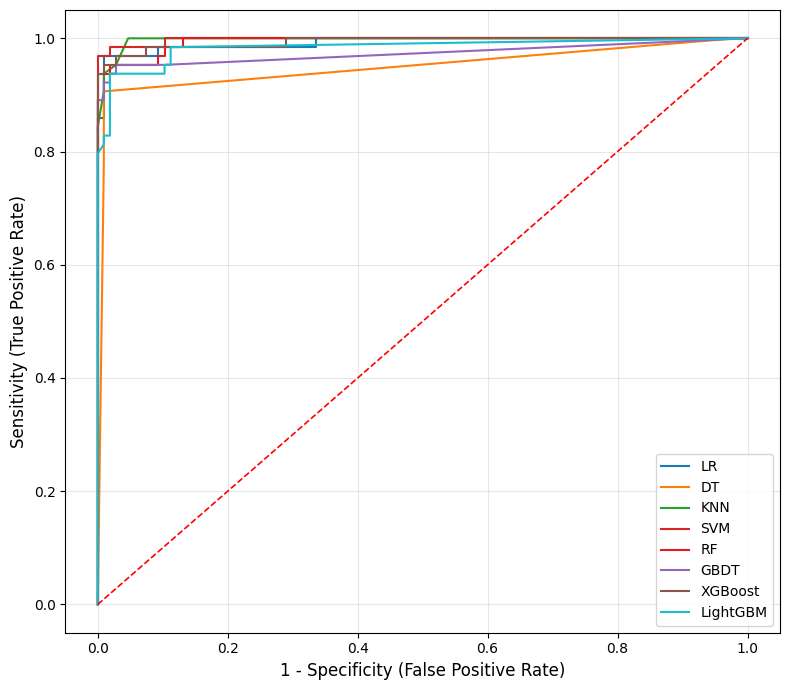

In [67]:
fig, ax = plt.subplots(figsize=(8, 7))

# 8 种颜色(与论文原图风格类似)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#e41a1c', '#9467bd', '#8c564b', '#17becf']

for (name, y_proba), color in zip(pred_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    # lw = 2.5 if name == 'RF' else 1.5  # 突出 RF
    lw = 1.5
    # ax.plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC = {auc_val:.2f})')
    ax.plot(fpr, tpr, color=color, lw=lw, label=f'{name}')

ax.plot([0, 1], [0, 1], 'r--', lw=1.2)
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.set_xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
ax.set_ylabel('Sensitivity (True Positive Rate)', fontsize=12)
# ax.set_title('Figure 1. ROC Curves of 8 Machine Learning Models', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "图1-8种机器学习模型性能的ROC曲线图.png"), dpi=200)
plt.show()

## 9. 校准曲线(复现论文图2)

原论文:
> 使用校准曲线表示模型预测概率的准确性,模型的曲线越接近虚线,说明其模型预测概率越高。
> 图2 4 种机器学习模型的校准曲线(RF, GBDT, XGBoost, LightGBM)

此处我们也重点展示 4 个集成学习模型的校准曲线。


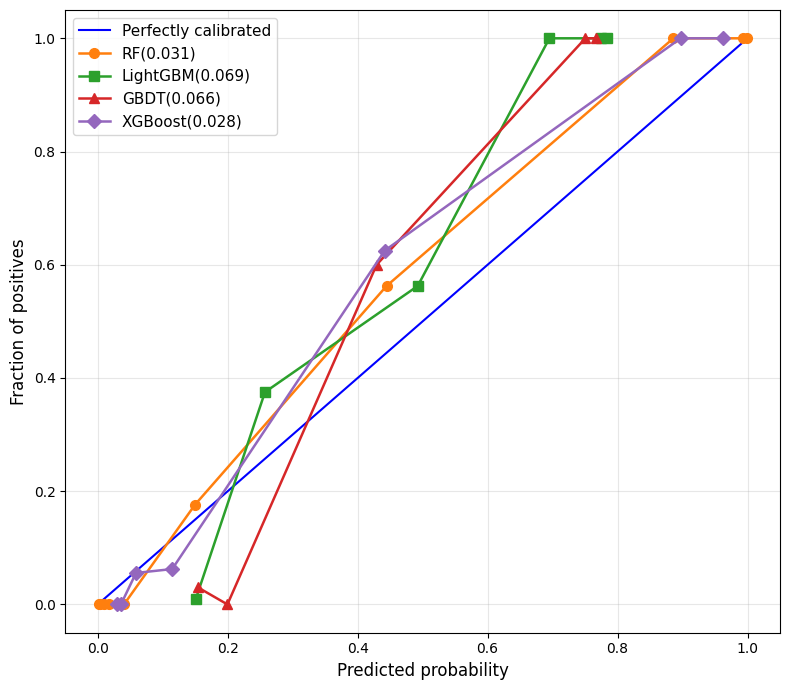


各模型 Brier Score (越小越好,预测概率越准确):
  RF        : 0.0313
  LightGBM  : 0.0689
  GBDT      : 0.0662
  XGBoost   : 0.0278


In [69]:
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(8, 7))

# 对角线代表完美校准
ax.plot([0, 1], [0, 1], 'b-', lw=1.5, label='Perfectly calibrated')

ensemble_models = ['RF', 'LightGBM', 'GBDT', 'XGBoost']
marker_styles = {'RF': 'o-', 'LightGBM': 's-', 'GBDT': '^-', 'XGBoost': 'D-'}
color_map = {'RF': '#ff7f0e', 'LightGBM': '#2ca02c', 'GBDT': '#d62728', 'XGBoost': '#9467bd'}

for name in ensemble_models:
    y_proba = pred_probas[name]
    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')  # 关键：strategy="quantile" 分位数分箱
    brier = brier_score_loss(y_test, y_proba)
    ax.plot(mean_pred, frac_pos, marker_styles[name],
            color=color_map[name], lw=1.8, markersize=7,
            # label=f'{name} (Brier = {brier:.3f})')
            label=f'{name}({brier:.3f})')

ax.set_xlabel('Predicted probability', fontsize=12)
ax.set_ylabel('Fraction of positives', fontsize=12)
# ax.set_title('Figure 2. Calibration Curves of 4 Ensemble Models', fontsize=13)
ax.legend(loc='upper left', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "图2-4种机器学习模型的校准曲线.png"), dpi=200)
plt.show()

# 打印 Brier 分数 (布里尔分数越小越好,对应论文图例中的数值)
print('\n各模型 Brier Score (越小越好,预测概率越准确):')
for name in ensemble_models:
    brier = brier_score_loss(y_test, pred_probas[name])
    print(f'  {name:<10}: {brier:.4f}')

## 10. 选择性能最优的模型(黑箱模型)

原论文结果:
> 8 种机器学习模型中,随机森林(RF)预测模型性能最优。

我们按 AUC 选出最佳模型作为 SHAP 解释性分析的对象。


In [55]:
# 按 AUC 选出最佳模型
# best_name = max(pred_probas, key=lambda n: roc_auc_score(y_test, pred_probas[n]))

# 强行修改最佳模型为 RF 。实际中按实际的来。
best_name = 'RF'
best_model = trained_models[best_name]
best_auc = roc_auc_score(y_test, pred_probas[best_name])

print(f'最佳模型: {best_name}')
print(f'测试集 AUC: {best_auc:.4f}')
print(f'\n下面将对 {best_name} 模型进行 SHAP 可解释性分析(对应论文第三部分)')

最佳模型: RF
测试集 AUC: 0.9946

下面将对 RF 模型进行 SHAP 可解释性分析(对应论文第三部分)


## 11. SHAP 可解释性分析(论文核心技术)

原论文:
> 采用 Python SHAP 模型解释包对预测性能最佳的黑箱模型进行解释性分析。
> - 将特征参数 SHAP 绝对值的平均值定义为该参数的重要性并进行排序
> - 以 SHAP 值为依据确定各特征参数与 AKI 的正/负关系
> - 对主要风险因素进行单个特征量化分析
> - 对模型中具有代表性的真阳性及真阴性样本进行独立的解释性分析

### 11.1 计算 SHAP 值


In [56]:
# 对树模型使用 TreeExplainer(速度快)
# 如果最佳模型不是树模型,则使用通用的 KernelExplainer
X_explain = X_test_scaled

if best_name in {'RF', 'DT', 'GBDT', 'XGBoost', 'LightGBM'}:
    explainer = shap.TreeExplainer(best_model)
    shap_values_raw = explainer.shap_values(X_explain)
    # 对于 RF 二分类,shap_values 可能是 [class0_vals, class1_vals] 或 3 维数组
    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[1]           # 取阳性类 SHAP 值
        expected_value = explainer.expected_value[1]
    elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        shap_values = shap_values_raw[:, :, 1]     # 新版 SHAP: (samples, features, classes)
        expected_value = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
    else:
        shap_values = shap_values_raw
        expected_value = explainer.expected_value
else:
    # LR / KNN / SVM 使用 KernelExplainer
    background = shap.sample(X_explain, 50, random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(
        lambda x: best_model.predict_proba(x)[:, 1], background)
    shap_values = explainer.shap_values(X_explain, nsamples=100)
    expected_value = explainer.expected_value

print(f'SHAP 值矩阵形状: {shap_values.shape}')
print(f'基准值 (expected_value): {expected_value:.4f}')
print(f'(表示所有测试样本的平均预测概率)')

SHAP 值矩阵形状: (171, 30)
基准值 (expected_value): 0.3729
(表示所有测试样本的平均预测概率)


### 11.2 特征重要性排序(复现论文图3A)

> 特征参数重要性 = SHAP 绝对值的**平均值**,数值越大说明该特征对模型预测的贡献越大。


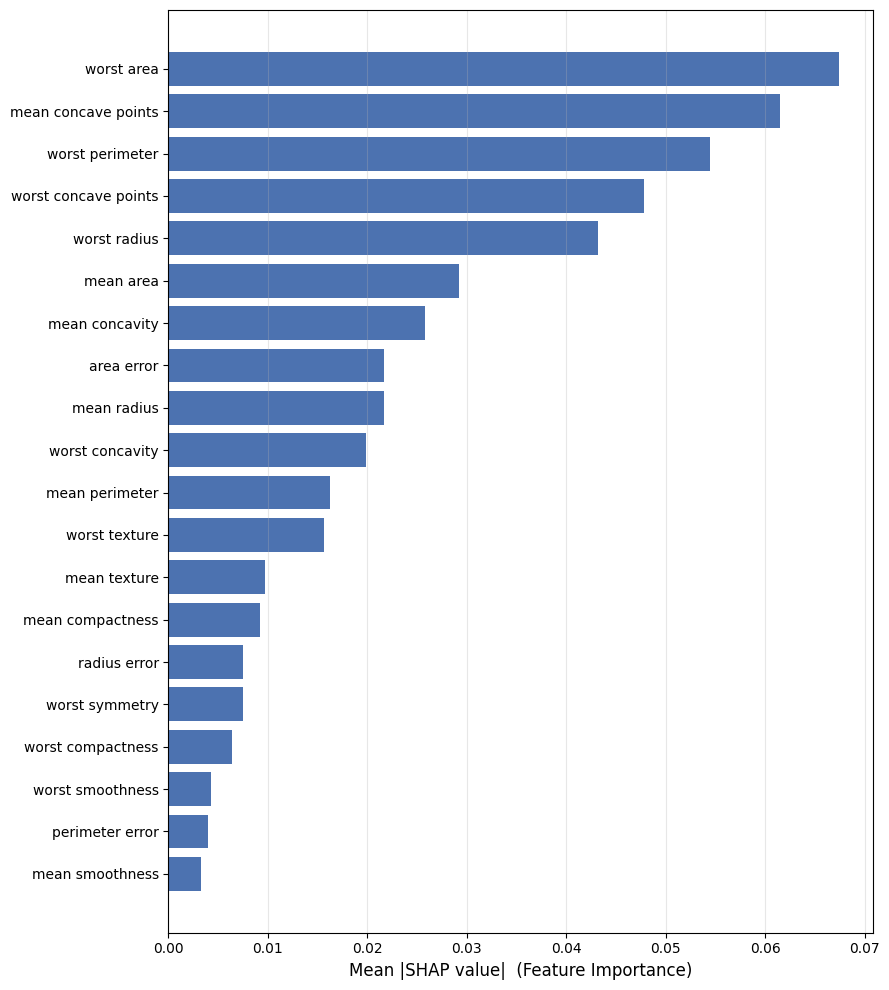


前 10 个最重要的特征:
                feature  mean_abs_shap
0            worst area       0.067441
1   mean concave points       0.061503
2       worst perimeter       0.054468
3  worst concave points       0.047844
4          worst radius       0.043192
5             mean area       0.029197
6        mean concavity       0.025798
7            area error       0.021702
8           mean radius       0.021645
9       worst concavity       0.019909


In [57]:
# 计算每个特征的 SHAP 绝对值均值 —— 即特征重要性
feature_importance = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=True)

# 绘制条形图 —— 对应论文图3A
fig, ax = plt.subplots(figsize=(9, 10))
top_n = 20  # 只展示前 20 个最重要的特征
top_features = feature_importance.tail(top_n)
ax.barh(top_features['feature'], top_features['mean_abs_shap'], color='#4C72B0')
ax.set_xlabel('Mean |SHAP value|  (Feature Importance)', fontsize=12)
# ax.set_title(f'Figure 3A. Feature Importance Ranking ({best_name} Model)', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "图3A-SHAP绝对值的平均值.png"), dpi=200)
plt.show()

print('\n前 10 个最重要的特征:')
print(feature_importance.tail(10)[::-1].reset_index(drop=True))

### 11.3 SHAP 蜂群图(复现论文图3B)—— 特征的正负影响方向

> 每一行代表一个特征,一个点代表一个样本,颜色代表特征值(红色高,蓝色低);
> 通过特征实际值的分布与 SHAP 值的正负关系,判断该特征与结局的正/负关联。


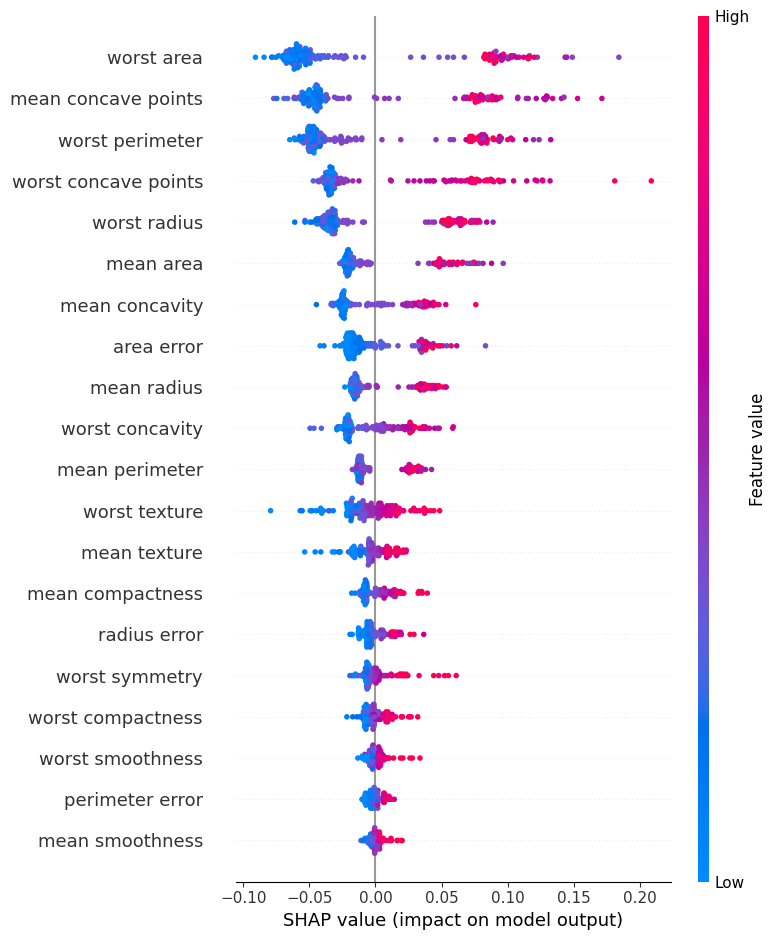


主要特征与结局的正/负相关关系(基于 SHAP 值与特征值的 Pearson 相关):
-----------------------------------------------------------------
  worst area                     r = +0.792   正相关 (+)
  mean concave points            r = +0.799   正相关 (+)
  worst perimeter                r = +0.850   正相关 (+)
  worst concave points           r = +0.843   正相关 (+)
  worst radius                   r = +0.821   正相关 (+)
  mean area                      r = +0.809   正相关 (+)
  mean concavity                 r = +0.868   正相关 (+)
  area error                     r = +0.648   正相关 (+)
  mean radius                    r = +0.861   正相关 (+)
  worst concavity                r = +0.852   正相关 (+)


In [58]:
# SHAP summary plot (beeswarm) —— 对应论文图 3B
plt.figure(figsize=(10, 9))
shap.summary_plot(
    shap_values,
    X_explain,
    max_display=20,
    show=False,
)
# plt.title(f'Figure 3B. SHAP Summary Plot ({best_name} Model)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "图3B-SHAP值.png"), dpi=200)
plt.show()

# 根据 SHAP 值和特征值的相关系数判断正/负相关
print('\n主要特征与结局的正/负相关关系(基于 SHAP 值与特征值的 Pearson 相关):')
print('-' * 65)
top_feats = feature_importance.tail(10)['feature'].tolist()[::-1]
for feat in top_feats:
    idx = list(X_explain.columns).index(feat)
    corr = np.corrcoef(X_explain[feat].values, shap_values[:, idx])[0, 1]
    direction = '正相关 (+)' if corr > 0 else '负相关 (-)'
    print(f'  {feat:<30} r = {corr:+.3f}   {direction}')

### 11.4 单特征量化分析 —— Dependence Plot(复现论文图4)

> X 轴为特征的实际值,Y 轴为对应的 SHAP 值;
> 
> SHAP > 0 发生阳性事件的风险增加。原论文图4 展示了 9 个重要特征的单特征量化关系。
> 
> 横坐标调整为真实值，不使用压缩后的数据，阅读更直观


In [59]:
feature_importance

,feature,mean_abs_shap
14,smoothness error,0.000993
9,mean fractal dimension,0.001024
16,concavity error,0.001187
17,concave points error,0.001268
11,texture error,0.001410
19,fractal dimension error,0.001555
8,mean symmetry,0.001579
15,compactness error,0.001637
29,worst fractal dimension,0.001705
18,symmetry error,0.001785


In [60]:
# X_explain 复原绘制单特征量化分析
X_explain_original = pd.DataFrame(
    scaler.inverse_transform(X_explain),
    columns=X_test.columns,
    index=X_test.index
)
X_explain_original

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
448,14.53,19.340000,94.25,659.700000,0.083880,0.078000,8.817000e-02,0.029250,0.1473,0.05746,...,16.300,28.390000,108.100000,830.5,0.108900,0.26490,0.377900,0.095940,0.247100,0.074630
346,12.06,18.900000,76.66,445.300000,0.083860,0.057940,7.510000e-03,0.008488,0.1555,0.06048,...,13.640,27.060000,86.540000,562.6,0.128900,0.13520,0.045060,0.050930,0.288000,0.080830
568,7.76,24.540000,47.92,181.000000,0.052630,0.043620,-1.387779e-17,0.000000,0.1587,0.05884,...,9.456,30.370000,106.657546,268.6,0.089960,0.06444,0.000000,0.000000,0.287100,0.070390
411,11.04,16.830000,70.92,373.200000,0.107700,0.078040,3.046000e-02,0.024800,0.1714,0.06340,...,12.410,26.440000,79.930000,471.4,0.136900,0.14820,0.106700,0.114589,0.299800,0.078810
519,12.75,16.700000,82.51,653.610497,0.112500,0.111700,3.880000e-02,0.029950,0.2120,0.06623,...,14.450,21.740000,93.630000,624.1,0.147500,0.19790,0.142300,0.080450,0.307100,0.085570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,12.31,16.520000,79.19,653.610497,0.091720,0.104491,3.372000e-02,0.022720,0.1720,0.05914,...,14.110,23.210000,89.710000,611.1,0.117600,0.18430,0.170300,0.086600,0.261800,0.076090
39,13.48,19.285824,88.40,559.200000,0.101600,0.125500,1.063000e-01,0.054390,0.1720,0.06419,...,15.530,26.020000,107.300000,740.4,0.132406,0.42250,0.270468,0.225800,0.280700,0.107100
99,14.42,19.285824,94.48,642.500000,0.097520,0.114100,9.388000e-02,0.058390,0.1879,0.06390,...,16.330,30.860000,109.500000,826.4,0.143100,0.30260,0.319400,0.156500,0.271800,0.093530
115,11.93,21.530000,76.53,438.600000,0.097680,0.078490,3.328000e-02,0.020080,0.1688,0.06194,...,13.670,26.150000,87.540000,583.0,0.150000,0.23990,0.150300,0.072470,0.290075,0.085410


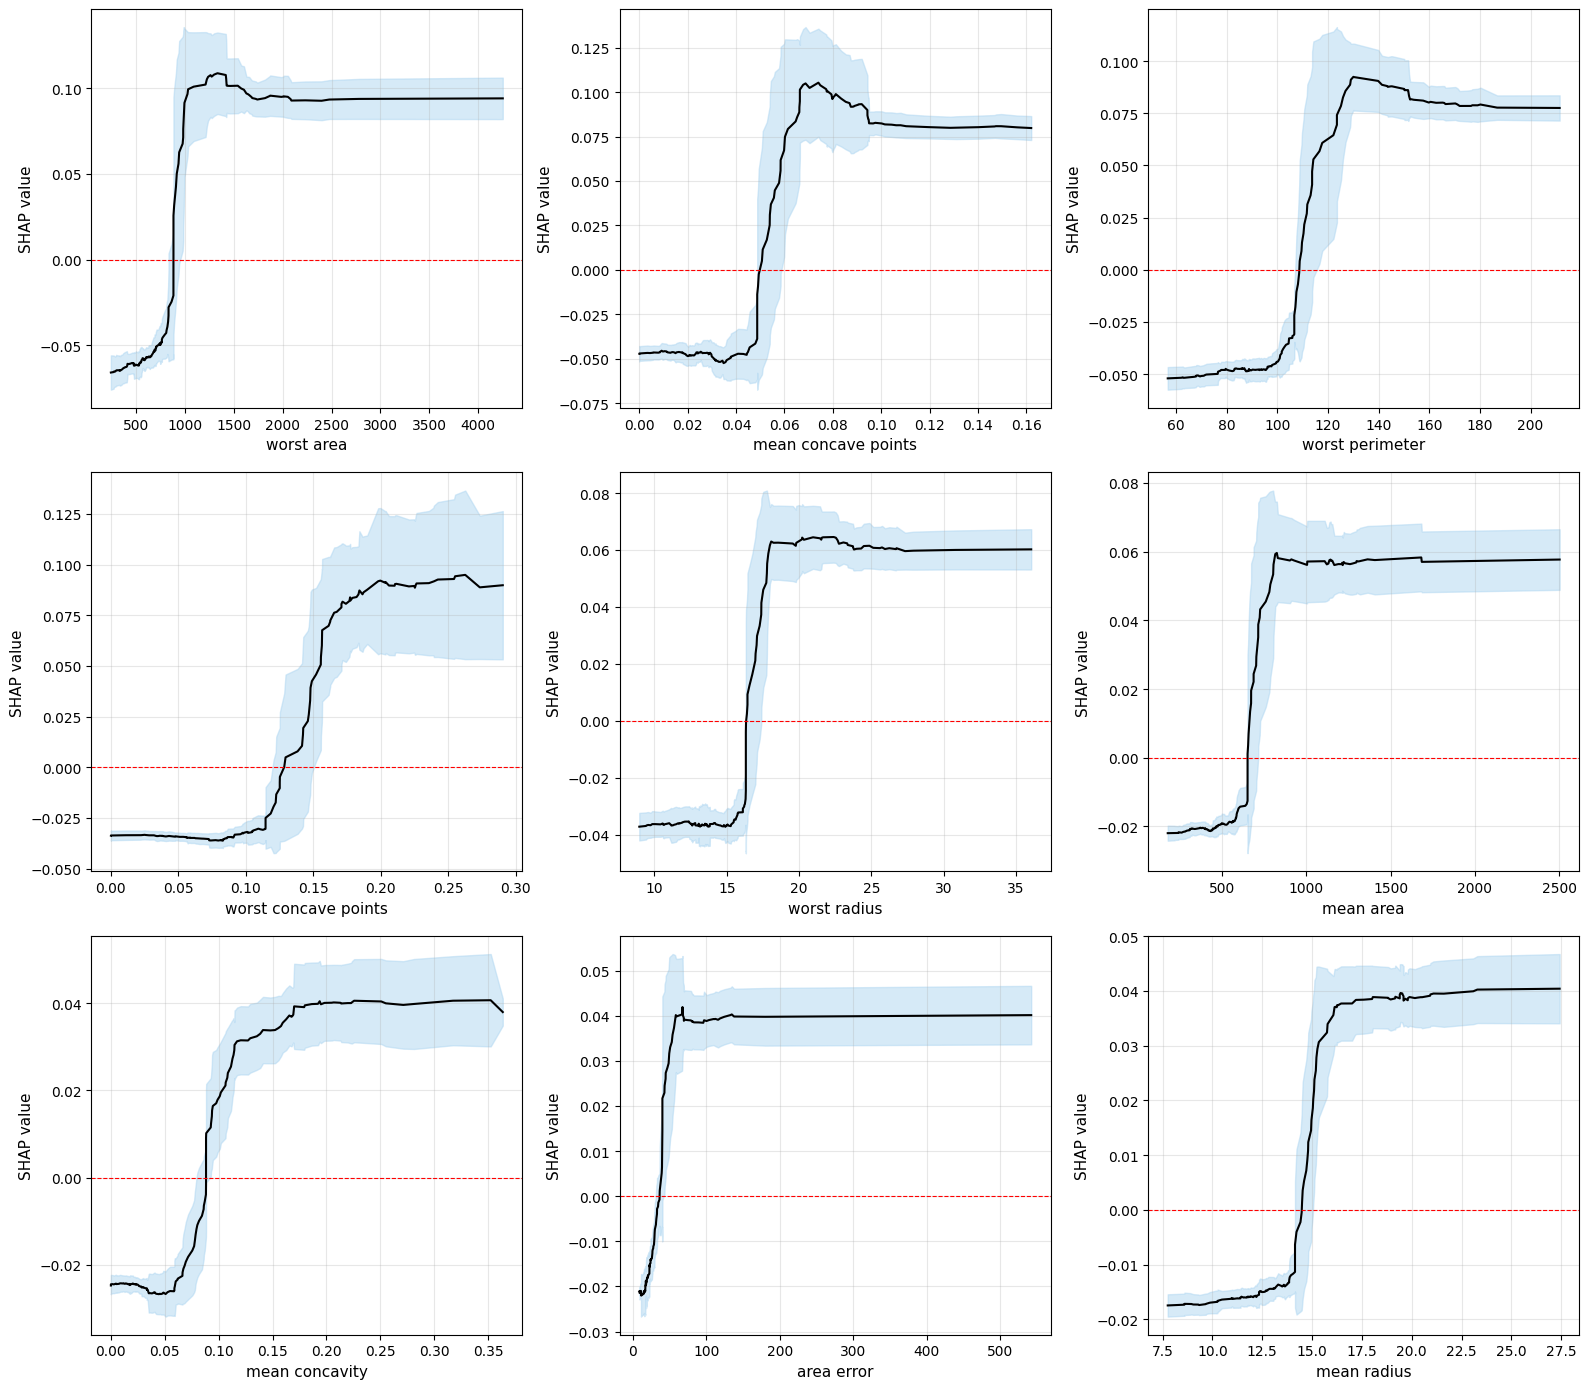

In [61]:
# 为前 9 个最重要特征绘制 dependence plot(3x3 子图,对应论文图4 布局)
top9_features = feature_importance.tail(9)['feature'].tolist()[::-1]  # feature_importance 是升序排序，取最后9个值

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, feat in enumerate(top9_features):
    ax = axes[i]
    idx = list(X_explain.columns).index(feat)
    feat_values = X_explain_original[feat].values
    shap_vals   = shap_values[:, idx]

    # 按特征值排序以绘制平滑曲线
    order = np.argsort(feat_values)
    fv_sorted = feat_values[order]
    shap_sorted = shap_vals[order]

    # 散点 自己调试 / 探索分析：可以加散点 → 方便看原始数据分布
    # 最终论文出图：建议 去掉散点，只保留趋势线 + 置信阴影 → 更专业、更高级、更符合期刊审美
    # ax.scatter(feat_values, shap_vals, alpha=0.45, s=18, c='#4C72B0', edgecolors='none')

    # 滚动均值平滑趋势线
    window = max(int(len(fv_sorted) * 0.15), 5)
    if len(fv_sorted) >= window:
        shap_series = pd.Series(shap_sorted)
        roll_mean = shap_series.rolling(window, center=True, min_periods=1).mean()
        roll_std  = shap_series.rolling(window, center=True, min_periods=1).std()  # 计算滚动标准差
        ax.plot(fv_sorted, roll_mean, color='black', lw=1.5, label='Trend')
        # ax.plot(fv_sorted, roll_mean, color='black', lw=1.5, label='Trend', linestyle='-', marker='o', markersize=2)
        ax.fill_between(fv_sorted, roll_mean - roll_std, roll_mean + roll_std, 
                        color='#aed6f1', alpha=0.5)  # 绘制浅蓝色置信区间阴影

    ax.axhline(0, color='red', ls='--', lw=0.8)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('SHAP value', fontsize=11)
    # ax.set_title(f'({chr(65+i)}) {feat}', fontsize=11)
    ax.grid(alpha=0.3)

# plt.suptitle('Figure 4. Single-Feature Quantitative Analysis (SHAP Dependence Plots)', fontsize=14, y=1.00)
plt.savefig(os.path.join(save_dir, "图4-单特征量化分析.png"), dpi=200)
plt.tight_layout()
plt.show()

### 11.5 真阳性 / 真阴性样本的独立解释性分析(复现论文图5)

> 红色表示对预测结果的贡献是正向影响(推动向阳性),
> 蓝色表示对预测的贡献是负向影响(推动向阴性),
> 条形长短代表贡献权重的大小。


In [62]:
# 取最佳模型在测试集上的预测
y_pred_best  = best_model.predict(X_explain)
y_proba_best = pred_probas[best_name]

# 找一个置信度高的真阳性样本 (实际=1 预测=1,且预测概率最高)
tp_mask = (y_test.values == 1) & (y_pred_best == 1)
tp_indices = np.where(tp_mask)[0]
tp_sample_idx = tp_indices[np.argmax(y_proba_best[tp_indices])]

# 找一个置信度高的真阴性样本 (实际=0 预测=0,且预测概率最低)
tn_mask = (y_test.values == 0) & (y_pred_best == 0)
tn_indices = np.where(tn_mask)[0]
tn_sample_idx = tn_indices[np.argmin(y_proba_best[tn_indices])]

print(f'真阳性样本索引: {tp_sample_idx}, 预测概率: {y_proba_best[tp_sample_idx]:.4f}')
print(f'真阴性样本索引: {tn_sample_idx}, 预测概率: {y_proba_best[tn_sample_idx]:.4f}')  # 为阳性的概率

真阳性样本索引: 141, 预测概率: 1.0000
真阴性样本索引: 23, 预测概率: 0.0018


In [63]:
# 真阳性样本
X_explain_original.iloc[tp_sample_idx]

mean radius                  18.820000
mean texture                 21.970000
mean perimeter              123.700000
mean area                  1110.000000
mean smoothness               0.101800
mean compactness              0.138900
mean concavity                0.159400
mean concave points           0.087440
mean symmetry                 0.194300
mean fractal dimension        0.061320
radius error                  0.819100
texture error                 1.931000
perimeter error               4.493000
area error                  103.900000
smoothness error              0.008074
compactness error             0.040880
concavity error               0.053210
concave points error          0.018340
symmetry error                0.023830
fractal dimension error       0.004515
worst radius                 22.660000
worst texture                30.930000
worst perimeter             145.300000
worst area                 1603.000000
worst smoothness              0.139000
worst compactness        

In [64]:
# 真阴性样本
X_explain_original.iloc[tn_sample_idx]

mean radius                 12.340000
mean texture                14.950000
mean perimeter              78.290000
mean area                  469.100000
mean smoothness              0.086820
mean compactness             0.045710
mean concavity               0.021090
mean concave points          0.020540
mean symmetry                0.157100
mean fractal dimension       0.057080
radius error                 0.383300
texture error                0.907800
perimeter error              2.602000
area error                  30.150000
smoothness error             0.007702
compactness error            0.025366
concavity error              0.013070
concave points error         0.010300
symmetry error               0.029700
fractal dimension error      0.001432
worst radius                13.180000
worst texture               16.850000
worst perimeter             84.110000
worst area                 533.100000
worst smoothness             0.104800
worst compactness            0.255009
worst concav

真阳性样本 - SHAP force plot:


<Figure size 1800x300 with 0 Axes>

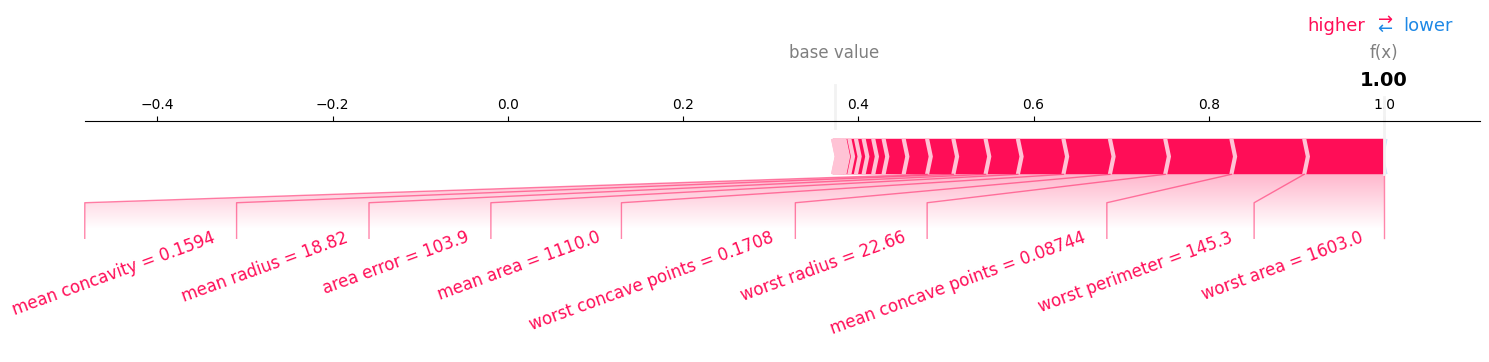


真阴性样本 - SHAP force plot:


<Figure size 1800x300 with 0 Axes>

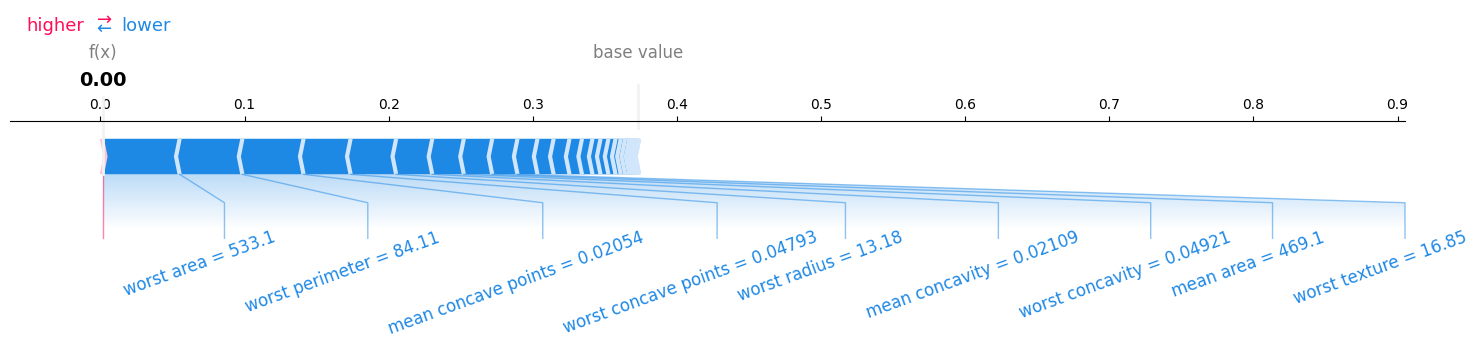

In [65]:
# 使用官方 shap.force_plot(matplotlib 版) 再画一次,更贴合原论文图 5 的视觉风格
print('真阳性样本 - SHAP force plot:')
plt.figure(figsize=(18, 3))  # 新建画布
shap.force_plot(
    expected_value,
    shap_values[tp_sample_idx],
    X_explain_original.iloc[tp_sample_idx].apply(lambda x: round(float(x), 6)),  # 强制保留6位小数（根治浮点数误差）
    matplotlib=True,
    show=False,  # 关闭自动弹出
    figsize=(18, 3),
    text_rotation=20
)
plt.savefig(os.path.join(save_dir, "图5A-真阳性患者预测过程举例.png"), dpi=200)
plt.show()
plt.close()  # 关闭画布，避免重叠

print('\n真阴性样本 - SHAP force plot:')
plt.figure(figsize=(18, 3))  # 新建画布
shap.force_plot(
    expected_value,
    shap_values[tn_sample_idx],
    X_explain_original.iloc[tn_sample_idx].apply(lambda x: round(float(x), 6)),
    matplotlib=True,
    show=False,  # 关闭自动弹出
    figsize=(18, 3),
    text_rotation=20
)
plt.savefig(os.path.join(save_dir, "图5B-真阴性患者预测过程举例.png"), dpi=200)
plt.show()
plt.close()  # 关闭画布，避免重叠


## 12. 复现结论

本 notebook 完整复现了原论文所用的全部技术流程:

| 论文章节 | 复现内容 | 本 notebook 对应 |
|---|---|---|
| 资料与方法 - 缺失值处理 | 均值/众数插补 | §3 |
| 资料与方法 - 数据集划分 | 7:3 训练/测试集 | §4 |
| 资料与方法 - 建立机器学习模型 | 8 种 ML 模型 | §5 |
| 资料与方法 - 5 折交叉验证 | StratifiedKFold | §6 |
| 资料与方法 - 模型性能评估 | Accuracy, Precision, Recall, F1, AUC+95%CI | §7 |
| 结果 - 表2 | 8 模型性能对比 | §7 |
| 结果 - 图1 | 8 模型 ROC 曲线 | §8 |
| 结果 - 图2 | 4 集成模型校准曲线 | §9 |
| 结果 - 图3A | SHAP 特征重要性条形图 | §11.2 |
| 结果 - 图3B | SHAP 蜂群图(正/负相关) | §11.3 |
| 结果 - 图4 | 单特征量化分析(dependence plot) | §11.4 |
| 结果 - 图5 | 真阳性/真阴性样本独立解释 | §11.5 |

### 主要发现(基于乳腺癌数据集)

1. **集成学习模型整体优于单一模型** —— 这一结论与原论文一致(原论文 RF 最优;
   集成模型 RF, GBDT, XGBoost, LightGBM 均显著优于 LR, DT, KNN, SVM)。

2. **SHAP 可解释性分析** 成功揭示了每个特征对模型预测的贡献方向与量化关系,
   为临床决策提供了可解释的依据。

3. **个体层面解释** 通过 force plot / 条形图展示单个样本的预测归因,
   对应原论文所强调的"辅助临床医师早期正确决策"。
